In [31]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import pytest
from scipy import stats

# Get project root (one level up from notebooks)
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.pipelines.preprocessing import MLDataPreprocessor

import matplotlib.pyplot as plt
import seaborn

In [32]:
# Initialize loader
data_path = r"C:\Users\jhoni\Documents\LooperAI\repositorios\ai-ml-mlops-katas\data\raw\Exam_Score_Prediction.csv"

data_loader = MLDataPreprocessor(data_path)

In [33]:
# Upload raw data
df_raw = data_loader.load_data()

Loaded 20000 registers


In [34]:
for i,row in df_raw.head(5).iterrows():
    print(f"{row['age']}\n")

17

23

22

20

20



In [35]:
# Count missing per column
missing_counts = df_raw.isnull().sum()
missing_counts

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [37]:
# Filter to only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
missing_counts

Series([], dtype: int64)

In [41]:
# Calculate missing percentage per column
missing_pct = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_pct

student_id          0.0
age                 0.0
gender              0.0
course              0.0
study_hours         0.0
class_attendance    0.0
internet_access     0.0
sleep_hours         0.0
sleep_quality       0.0
study_method        0.0
facility_rating     0.0
exam_difficulty     0.0
exam_score          0.0
dtype: float64

In [42]:
# Keep columns at or below threshold
cols_to_keep = missing_pct[missing_pct <= 30.0].index.tolist()
cols_to_keep

['student_id',
 'age',
 'gender',
 'course',
 'study_hours',
 'class_attendance',
 'internet_access',
 'sleep_hours',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty',
 'exam_score']

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [7]:
df_raw.select_dtypes(exclude=['object']).columns

Index(['student_id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score'],
      dtype='object')

In [8]:
df_raw.select_dtypes(include=['object']).columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [5]:
df_raw.head(10)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
5,6,23,male,b.tech,3.48,65.4,yes,4.2,good,mixed,low,moderate,58.2
6,7,17,female,b.tech,1.35,69.0,yes,7.4,average,online videos,high,hard,53.7
7,8,22,male,b.sc,5.48,51.1,yes,8.2,poor,self-study,low,moderate,47.3
8,9,18,other,bca,2.89,92.0,yes,6.6,poor,self-study,low,easy,44.9
9,10,17,male,bba,6.77,44.8,yes,9.8,average,group study,high,moderate,77.7


In [6]:
df_raw['exam_difficulty'].value_counts()

exam_difficulty
moderate    9878
easy        6141
hard        3981
Name: count, dtype: int64

In [20]:
# Remove high cardinality
df_remove_hc = data_loader.remove_high_cardinality(df_raw, 10)

In [21]:
df_eda = df_remove_hc[["student_id","exam_score"]]
df_eda

,student_id,exam_score
0,1,58.9
1,2,54.8
2,3,90.3
3,4,29.7
4,5,43.7
...,...,...
19995,19997,86.5
19996,19998,60.9
19997,19999,64.5
19998,20000,79.0


In [22]:
df_remove_hc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [8]:
# Split feature and target
X,y = data_loader.split_features_and_target(df_remove_hc, "exam_score")

In [9]:
y

0        58.9
1        54.8
2        90.3
3        29.7
4        43.7
         ... 
19995    86.5
19996    60.9
19997    64.5
19998    79.0
19999    71.0
Name: exam_score, Length: 20000, dtype: float64

In [10]:
# Split train, val, test datasets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [4]:
# test_basic.py
def add(a, b):
    return a + b

def test_add_positive_numbers():
    result = add(2, 3)
    assert result == 5

def test_add_negative_numbers():
    result = add(-2, -3)
    assert result == -5

def test_add_mixed():
    result = add(-2, 3)
    assert result == 1

In [ ]:
reference = pd.Series([4, 5, 4, 6, 5, 4, 5, 6, 5, 4]*100)
current = pd.Series([3,4,5,4,5,3,5,6,6,5]*100)
n_bins = 10

In [3]:
bin_edges = np.histogram_bin_edges(reference, bins=n_bins)
bin_edges

array([4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. ])

In [5]:
_, bin_edges = np.histogram(reference, bins=n_bins)
bin_edges

array([4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. ])

In [6]:
# Extend edges to handle values outside reference range
bin_edges[0] = -np.inf # All low values
bin_edges[-1] = np.inf # All high values

In [7]:
# Count values in each bin
ref_counts, _ = np.histogram(reference, bins=bin_edges)
curr_counts, _ = np.histogram(current, bins=bin_edges)

In [14]:
# Convert to percentages
ref_pct = ref_counts / len(reference)
curr_pct = curr_counts / len(current)

ref_pct, curr_pct

(array([0.4, 0. , 0. , 0. , 0. , 0.4, 0. , 0. , 0. , 0.2]),
 array([0.4, 0. , 0. , 0. , 0. , 0.4, 0. , 0. , 0. , 0.2]))

In [15]:
# Avoid division by zero and log(0)
ref_pct = np.maximum(ref_pct, 0.0001)
curr_pct = np.maximum(curr_pct, 0.0001)

ref_pct, curr_pct

(array([4.e-01, 1.e-04, 1.e-04, 1.e-04, 1.e-04, 4.e-01, 1.e-04, 1.e-04,
        1.e-04, 2.e-01]),
 array([4.e-01, 1.e-04, 1.e-04, 1.e-04, 1.e-04, 4.e-01, 1.e-04, 1.e-04,
        1.e-04, 2.e-01]))

In [16]:
psi = np.sum((curr_pct - ref_pct) * np.log(curr_pct / ref_pct))
psi

np.float64(0.0)

Text(0.5, 1.0, 'Distribution Comparison\nPSI = 0.0000')

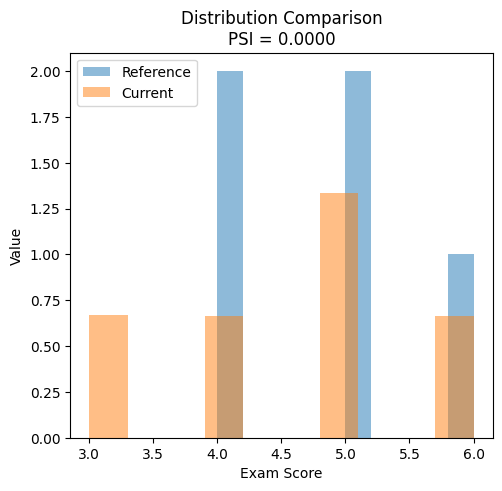

In [17]:
# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(reference, bins=n_bins, alpha=0.5, label='Reference', density=True)
plt.hist(current, bins=n_bins, alpha=0.5, label='Current', density=True)
plt.xlabel("Exam Score")
plt.ylabel('Value')
plt.legend()
plt.title(f'Distribution Comparison\nPSI = {psi:.4f}')

In [24]:
df_raw.shape

(20000, 13)

In [25]:
reference_df = df_raw.loc[:10000,:].copy()
reference_df.head(5)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [26]:
current_df = df_raw.loc[10000:,:].copy().reset_index(drop=True)
current_df.head(5)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,10001,19,male,b.tech,2.33,89.7,yes,9.6,poor,online videos,high,moderate,55.0
1,10002,18,female,diploma,0.97,84.0,yes,9.7,average,coaching,high,easy,55.5
2,10003,21,other,ba,0.86,91.9,yes,7.2,poor,online videos,high,easy,24.8
3,10004,22,male,diploma,0.08,96.9,yes,5.5,good,coaching,low,moderate,53.5
4,10005,19,male,b.com,7.83,73.9,yes,8.4,good,self-study,high,moderate,99.1


In [38]:
ref_counts_init = reference_df['course'].value_counts()
curr_counts_init = current_df['course'].value_counts()

In [42]:
curr_counts_init

course
b.com      1482
ba         1451
b.sc       1429
bca        1428
bba        1427
diploma    1416
b.tech     1367
Name: count, dtype: int64

In [40]:
# Handle new/missing categories
all_categories = set(ref_counts_init.index) | set(curr_counts_init.index)
all_categories

{'b.com', 'b.sc', 'b.tech', 'ba', 'bba', 'bca', 'diploma'}

In [41]:
ref_counts = ref_counts_init.reindex(all_categories, fill_value=0)
curr_counts = curr_counts_init.reindex(all_categories, fill_value=0)

In [43]:
curr_counts

course
b.sc       1429
diploma    1416
b.tech     1367
b.com      1482
bba        1427
bca        1428
ba         1451
Name: count, dtype: int64

In [46]:
drift_report = {}
# Chi-Square Test
# Expect counts = references proportions x current total
expected = ref_counts.values * (curr_counts.sum() / ref_counts.sum()) # type: ignore
expected

array([1448.85511449, 1409.8590141 , 1431.85681432, 1381.86181382,
       1408.85911409, 1473.85261474, 1444.85551445])

In [ ]:

chi2_stat, p_value = stats.chisquare(
    f_obs = curr_counts.values,
    f_exp = expected
)

drift_report['course'] = {
    'chi2_statistics': chi2_stat,
    'p_value': p_value,
    'drift_detected': p_value < pvalue_threshold,
    'reference_distribution': (ref_counts / ref_counts.sum()).to_dict(),
    'current_distribution': (curr_counts / curr_counts.sum()).to_dict()
}